CUISINE COMBINATION ANALYSIS

Total Restaurants: 9542

Top 10 Most Common Cuisine Combinations:
Cuisines
North Indian                      936
North Indian, Chinese             511
Chinese                           354
Fast Food                         354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Name: count, dtype: int64

Top 10 Highest Rated Cuisine Combinations:
Cuisines
North Indian, European, Mediterranean    4.460000
Burger                                   4.450000
Modern Indian                            4.345455
Indian                                   4.250000
International                            4.233333
Italian, Pizza, Sandwich                 4.220000
Steak                                    4.185714
French                                   4.185714
Cafe, Bakery, Desserts              

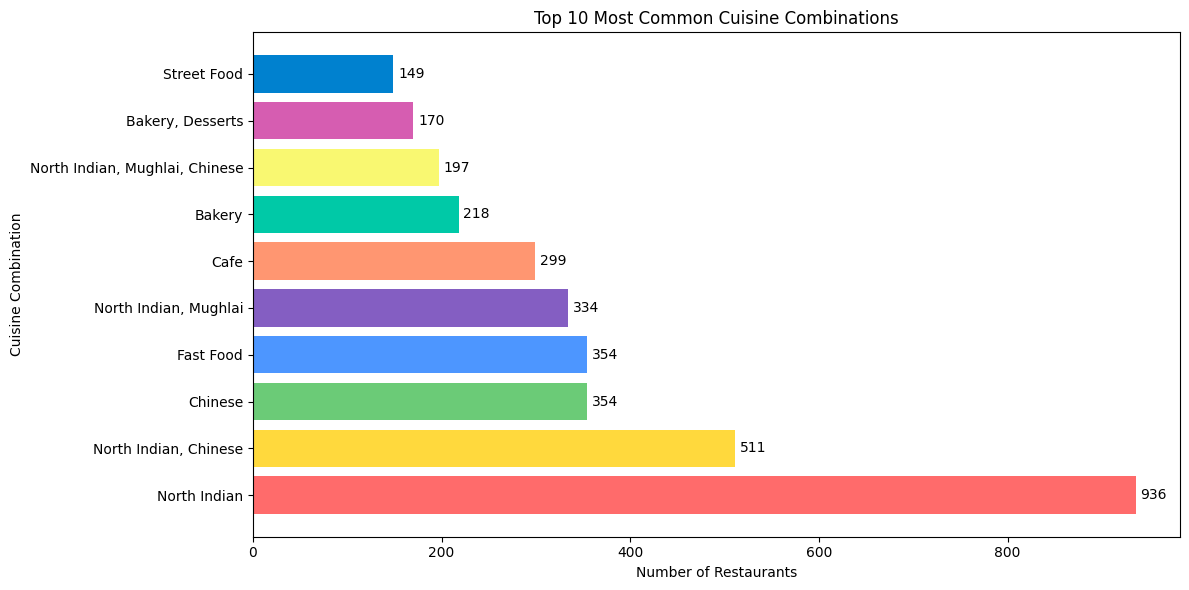

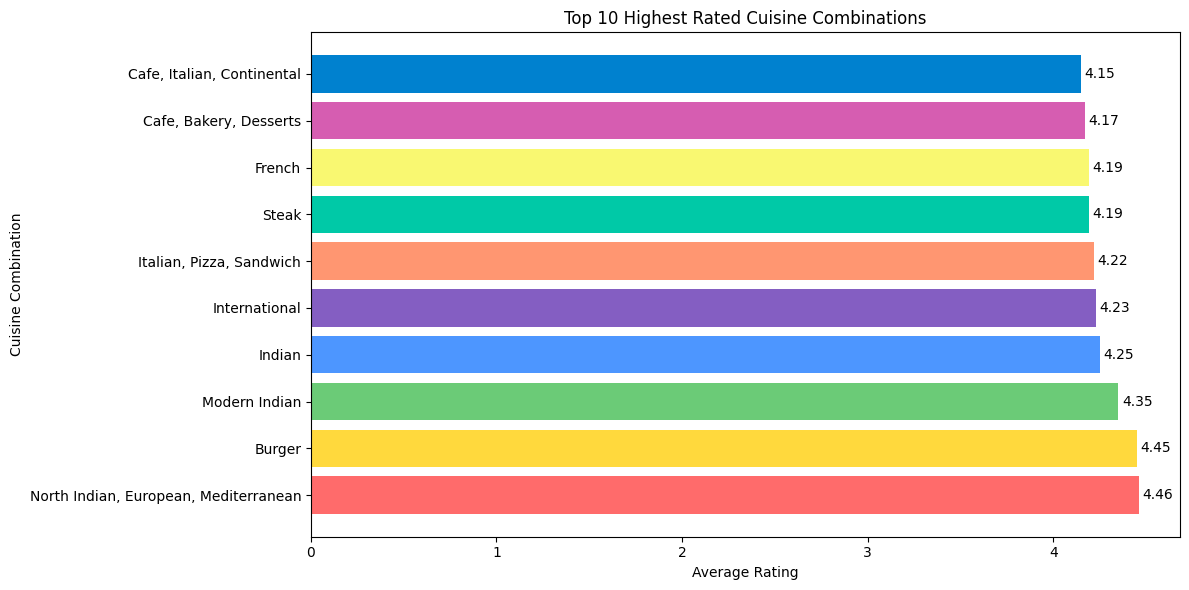

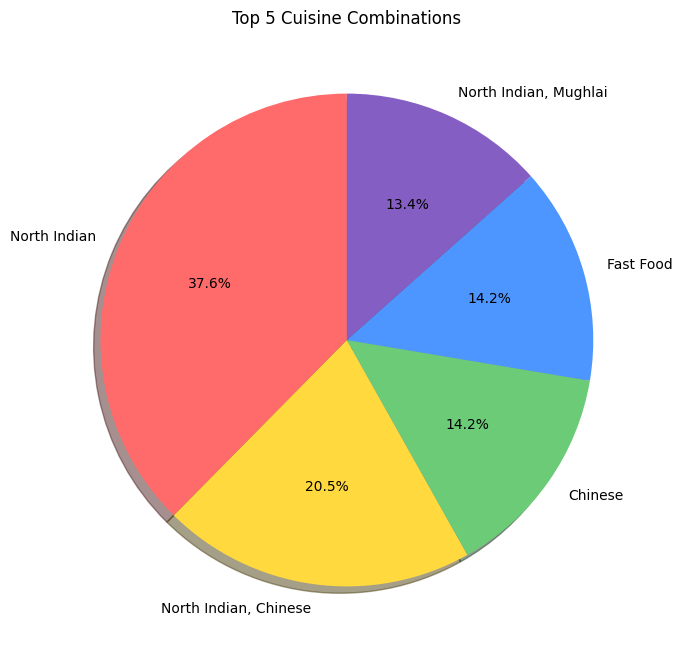


CONCLUSION

1. Most Common Cuisine Combination:
   North Indian

2. Number of Restaurants:
   936

3. Highest Rated Cuisine Combination:
   North Indian, European, Mediterranean

4. Average Rating:
   4.46

5. Certain cuisine combinations receive higher customer ratings than others.
Popular cuisine combinations are not always the highest rated, indicating differences between popularity and customer satisfaction.

Most Common Cuisine Combinations Table:
              Cuisine Combination  Restaurant Count
0                    North Indian               936
1           North Indian, Chinese               511
2                         Chinese               354
3                       Fast Food               354
4           North Indian, Mughlai               334
5                            Cafe               299
6                          Bakery               218
7  North Indian, Mughlai, Chinese               197
8                Bakery, Desserts               170
9                     

In [2]:
# ==========================================================
# Cognifyz Data Analysis Internship
# Level 2 - Task 2: Cuisine Combination Analysis
# ==========================================================

# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Load Dataset
# ----------------------------------------------------------

df = pd.read_csv(r"D:\2 Year iv sem\Python\Cognifyz-Data-Analysis\Dataset .csv")

# Remove missing cuisine values
df = df.dropna(subset=["Cuisines"])

print("=" * 60)
print("CUISINE COMBINATION ANALYSIS")
print("=" * 60)

print(f"\nTotal Restaurants: {len(df)}")

# ----------------------------------------------------------
# Top 10 Most Common Cuisine Combinations
# ----------------------------------------------------------

cuisine_counts = df["Cuisines"].value_counts()

top_combinations = cuisine_counts.head(10)

print("\nTop 10 Most Common Cuisine Combinations:")
print(top_combinations)

# ----------------------------------------------------------
# Average Rating by Cuisine Combination
# ----------------------------------------------------------

cuisine_ratings = (
    df.groupby("Cuisines")["Aggregate rating"]
    .mean()
    .sort_values(ascending=False)
)

# To avoid combinations having only 1 restaurant,
# consider combinations with at least 5 restaurants

cuisine_frequency = df["Cuisines"].value_counts()

valid_cuisines = cuisine_frequency[cuisine_frequency >= 5].index

filtered_ratings = cuisine_ratings.loc[
    cuisine_ratings.index.isin(valid_cuisines)
]

top_rated_cuisines = filtered_ratings.head(10)

print("\nTop 10 Highest Rated Cuisine Combinations:")
print(top_rated_cuisines)

# ----------------------------------------------------------
# Create Result Tables
# ----------------------------------------------------------

common_cuisines_df = pd.DataFrame({
    "Cuisine Combination": top_combinations.index,
    "Restaurant Count": top_combinations.values
})

rated_cuisines_df = pd.DataFrame({
    "Cuisine Combination": top_rated_cuisines.index,
    "Average Rating": top_rated_cuisines.round(2).values
})

print("\nMost Common Cuisine Combinations:")
print(common_cuisines_df)

print("\nHighest Rated Cuisine Combinations:")
print(rated_cuisines_df)

# ==========================================================
# VISUALIZATION 1
# Top 10 Most Common Cuisine Combinations
# ==========================================================

plt.figure(figsize=(12,6))

colors = [
    "#FF6B6B",
    "#FFD93D",
    "#6BCB77",
    "#4D96FF",
    "#845EC2",
    "#FF9671",
    "#00C9A7",
    "#F9F871",
    "#D65DB1",
    "#0081CF"
]

bars = plt.barh(
    common_cuisines_df["Cuisine Combination"],
    common_cuisines_df["Restaurant Count"],
    color=colors
)

plt.title("Top 10 Most Common Cuisine Combinations")
plt.xlabel("Number of Restaurants")
plt.ylabel("Cuisine Combination")

for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 5,
        bar.get_y() + bar.get_height()/2,
        int(width),
        va='center'
    )

plt.tight_layout()
plt.show()

# ==========================================================
# VISUALIZATION 2
# Top 10 Highest Rated Cuisine Combinations
# ==========================================================

plt.figure(figsize=(12,6))

bars = plt.barh(
    rated_cuisines_df["Cuisine Combination"],
    rated_cuisines_df["Average Rating"],
    color=colors
)

plt.title("Top 10 Highest Rated Cuisine Combinations")
plt.xlabel("Average Rating")
plt.ylabel("Cuisine Combination")

for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 0.02,
        bar.get_y() + bar.get_height()/2,
        round(width, 2),
        va='center'
    )

plt.tight_layout()
plt.show()

# ==========================================================
# VISUALIZATION 3
# Pie Chart - Top 5 Cuisine Combinations
# ==========================================================

plt.figure(figsize=(8,8))

plt.pie(
    top_combinations.head(5),
    labels=top_combinations.head(5).index,
    autopct="%1.1f%%",
    colors=colors[:5],
    startangle=90,
    shadow=True
)

plt.title("Top 5 Cuisine Combinations")

plt.show()

# ==========================================================
# Additional Analysis
# ==========================================================

highest_rated = top_rated_cuisines.idxmax()
highest_rating = round(top_rated_cuisines.max(), 2)

most_common = top_combinations.idxmax()
most_common_count = top_combinations.max()

# ==========================================================
# Conclusion
# ==========================================================

print("\n" + "=" * 60)
print("CONCLUSION")
print("=" * 60)

print(
    f"\n1. Most Common Cuisine Combination:"
    f"\n   {most_common}"
)

print(
    f"\n2. Number of Restaurants:"
    f"\n   {most_common_count}"
)

print(
    f"\n3. Highest Rated Cuisine Combination:"
    f"\n   {highest_rated}"
)

print(
    f"\n4. Average Rating:"
    f"\n   {highest_rating}"
)

print(
    "\n5. Certain cuisine combinations receive "
    "higher customer ratings than others."
)

print(
    "Popular cuisine combinations are not always "
    "the highest rated, indicating differences "
    "between popularity and customer satisfaction."
)

# ----------------------------------------------------------
# Final Tables
# ----------------------------------------------------------

print("\nMost Common Cuisine Combinations Table:")
print(common_cuisines_df)

print("\nHighest Rated Cuisine Combinations Table:")
print(rated_cuisines_df)